In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import math
import missingno as msno

In [2]:
eda_dir = Path("../results/eda")
eda_dir.mkdir(parents=True, exist_ok=True)
eda_dir

WindowsPath('../results/eda')

In [3]:
#Load clean dataset 
processed_dir = Path("D:\Erdos\Data Science Bootcamp\early_diabetes_screening\data\processed")
df_clean = pd.read_csv(processed_dir / "clean_project_dataset.csv")
print(df_clean.shape)
df_clean.head()

(9232, 37)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,BPXOSY1,BPXOSY2,...,ALQ111,ALQ121,ALQ130,DBQ700,DBD895,DBD900,DBD905,DBD910,doctor_diabetes,diabetes
0,109266.0,29.0,2.0,6.0,5.0,5.00,37.8,117.9,99.0,99.0,...,1.0,10.0,1.0,3.0,7.0,0.0,0.0,5.0,0.0,0
1,109267.0,21.0,2.0,2.0,4.0,5.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,4.0,0.0,0.0,0.0,0.0,0
2,109271.0,49.0,1.0,3.0,2.0,NaN,29.7,120.4,102.0,108.0,...,1.0,0.0,NaN,3.0,2.0,2.0,0.0,0.0,0.0,0
3,109273.0,36.0,1.0,3.0,4.0,0.83,21.9,86.8,116.0,110.0,...,1.0,0.0,NaN,4.0,2.0,2.0,0.0,7.0,0.0,0
4,109274.0,68.0,1.0,7.0,4.0,1.20,30.2,109.6,138.0,132.0,...,1.0,4.0,2.0,2.0,0.0,NaN,0.0,0.0,1.0,1


In [4]:
# Basic dataset info
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9232 entries, 0 to 9231
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SEQN             9232 non-null   float64
 1   RIDAGEYR         9232 non-null   float64
 2   RIAGENDR         9232 non-null   float64
 3   RIDRETH3         9232 non-null   float64
 4   DMDEDUC2         9217 non-null   float64
 5   INDFMPIR         7828 non-null   float64
 6   BMXBMI           8381 non-null   float64
 7   BMXWAIST         8055 non-null   float64
 8   BPXOSY1          7648 non-null   float64
 9   BPXOSY2          7637 non-null   float64
 10  BPXOSY3          7619 non-null   float64
 11  BPXODI1          7648 non-null   float64
 12  BPXODI2          7637 non-null   float64
 13  BPXODI3          7619 non-null   float64
 14  DIQ010           9227 non-null   float64
 15  LBXGH            8081 non-null   float64
 16  LBXGLU           4004 non-null   float64
 17  BPQ020        

In [5]:
print("Number of rows:", df_clean.shape[0])
print("Number of columns:", df_clean.shape[1])

Number of rows: 9232
Number of columns: 37


In [6]:
#check duplicate participants 
print("unique participants:", df_clean["SEQN"].nunique())
print("Duplicate participant count:",df_clean["SEQN"].duplicated().sum())

unique participants: 9232
Duplicate participant count: 0


In [7]:
# Diabetes target distribution
target_counts = df_clean["diabetes"].value_counts()
target_percent = df_clean["diabetes"].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percent.round(2))

Target counts:
diabetes
0    7412
1    1820
Name: count, dtype: int64

Target percentages:
diabetes
0    80.29
1    19.71
Name: proportion, dtype: float64


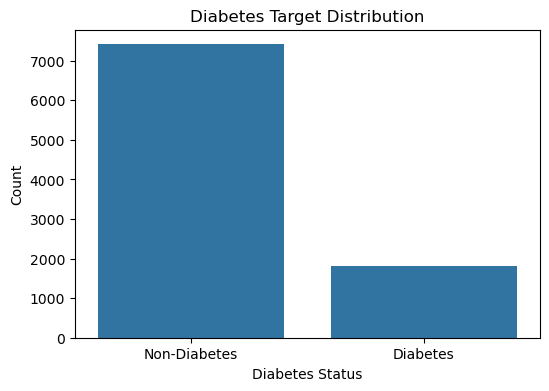

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="diabetes")
plt.title("Diabetes Target Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.xticks([0, 1], ["Non-Diabetes", "Diabetes"])
plt.savefig(eda_dir / "diabetes_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# Numeric variables for EDA
numeric_cols = [
    "RIDAGEYR",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "BPXOSY1", 
    "BPXOSY2", 
    "BPXOSY3",
    "BPXODI1", 
    "BPXODI2", 
    "BPXODI3",
    "PAQ655", 
    "PAD660",
    "PAQ670", 
    "PAD675",
    "PAD680",
    "ALQ130",
    "DBD895", 
    "DBD900", 
    "DBD905", 
    "DBD910"
]

# Keep only columns that exist in the dataset
numeric_cols = [col for col in numeric_cols if col in df_clean.columns]

# Categorical variables for EDA
categorical_cols = [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "BPQ020",
    "BPQ080",
    "SMQ020",
    "PAQ650",
    "PAQ665",
    "ALQ111",
    "ALQ121",
    "DBQ700"
]

categorical_cols = [col for col in categorical_cols if col in df_clean.columns]

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['RIDAGEYR', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'BPXOSY1', 'BPXOSY2', 'BPXOSY3', 'BPXODI1', 'BPXODI2', 'BPXODI3', 'PAQ655', 'PAD660', 'PAQ670', 'PAD675', 'PAD680', 'ALQ130', 'DBD895', 'DBD900', 'DBD905', 'DBD910']

Categorical columns:
['RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'BPQ020', 'BPQ080', 'SMQ020', 'PAQ650', 'PAQ665', 'ALQ111', 'ALQ121', 'DBQ700']


In [10]:
# Summary statistics for numeric variables 
df_clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
RIDAGEYR,9232.0,51.144931,17.686659,2.000000e+01,36.00,52.00,65.0000,80.0
INDFMPIR,7828.0,2.597786,1.626501,5.397605e-79,1.19,2.21,4.2025,5.0
BMXBMI,8381.0,30.039017,7.565943,1.420000e+01,24.90,28.80,33.8000,92.3
BMXWAIST,8055.0,100.987039,17.130987,5.790000e+01,89.00,99.50,111.5000,187.5
BPXOSY1,7648.0,125.075052,19.947541,6.600000e+01,111.00,122.00,136.0000,225.0
BPXOSY2,7637.0,124.791672,19.746599,6.900000e+01,111.00,122.00,136.0000,222.0
BPXOSY3,7619.0,124.691823,19.553302,6.000000e+01,111.00,122.00,135.0000,220.0
BPXODI1,7648.0,75.205936,11.943487,3.600000e+01,67.00,74.00,82.0000,151.0
BPXODI2,7637.0,74.638209,11.897873,3.100000e+01,66.00,74.00,82.0000,146.0
BPXODI3,7619.0,74.325502,11.932551,3.600000e+01,66.00,74.00,82.0000,145.0


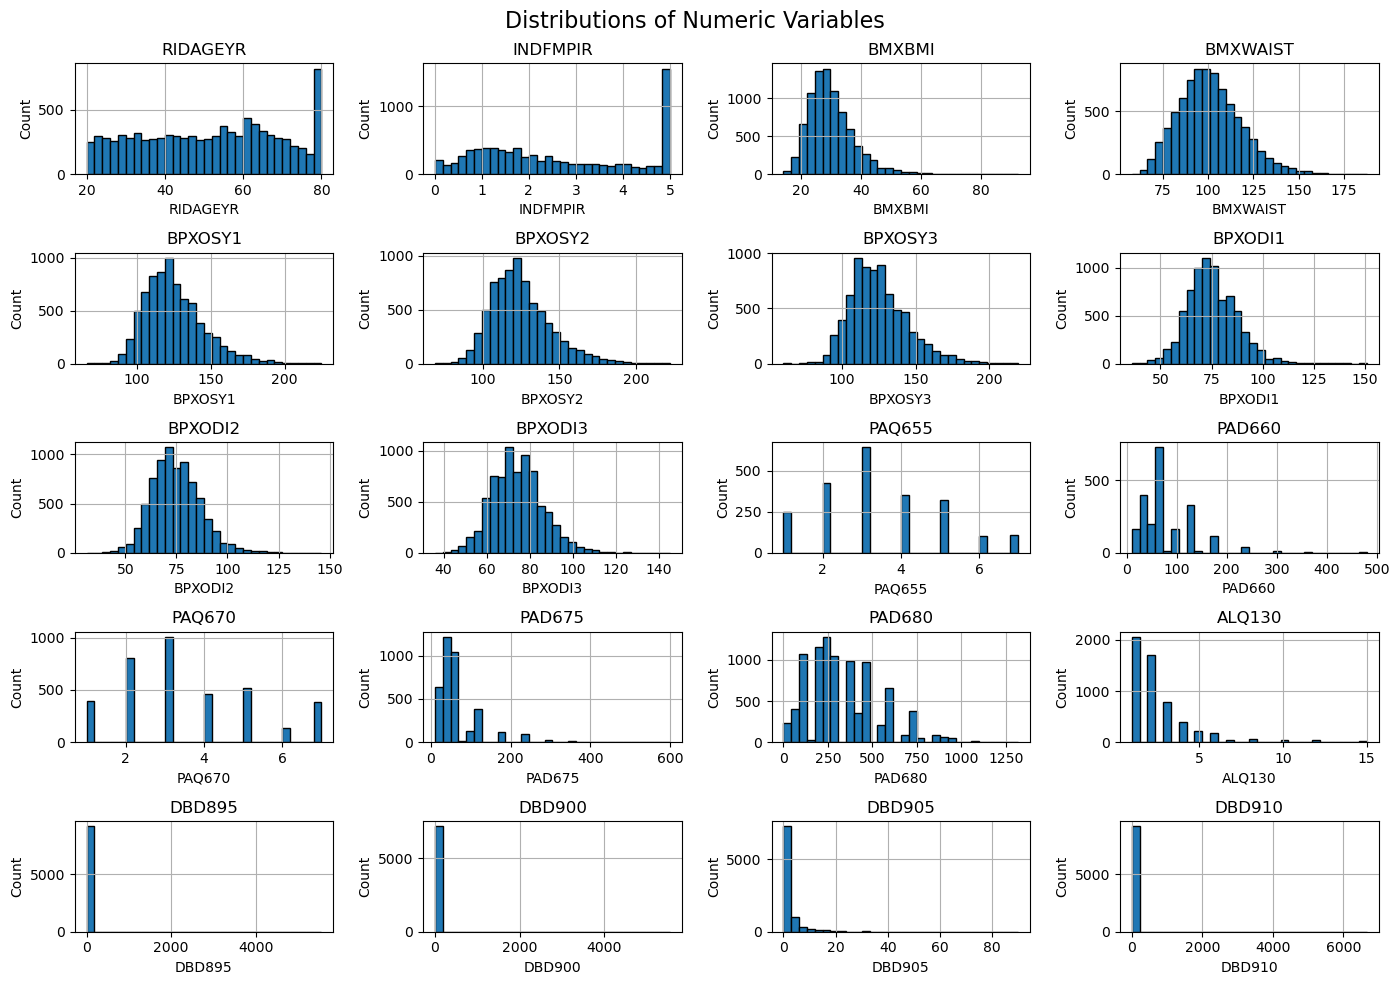

In [11]:
# Histogram for numeric variables
axes = df_clean[numeric_cols].hist(
    bins=30,
    figsize=(14, 10),
    edgecolor="black"
)
plt.suptitle("Distributions of Numeric Variables", fontsize=16)
for ax in axes.flatten():
    ax.set_xlabel(ax.get_title())
    ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(eda_dir / "distribution_numeric_variables.png", dpi=300, bbox_inches="tight")
plt.show()

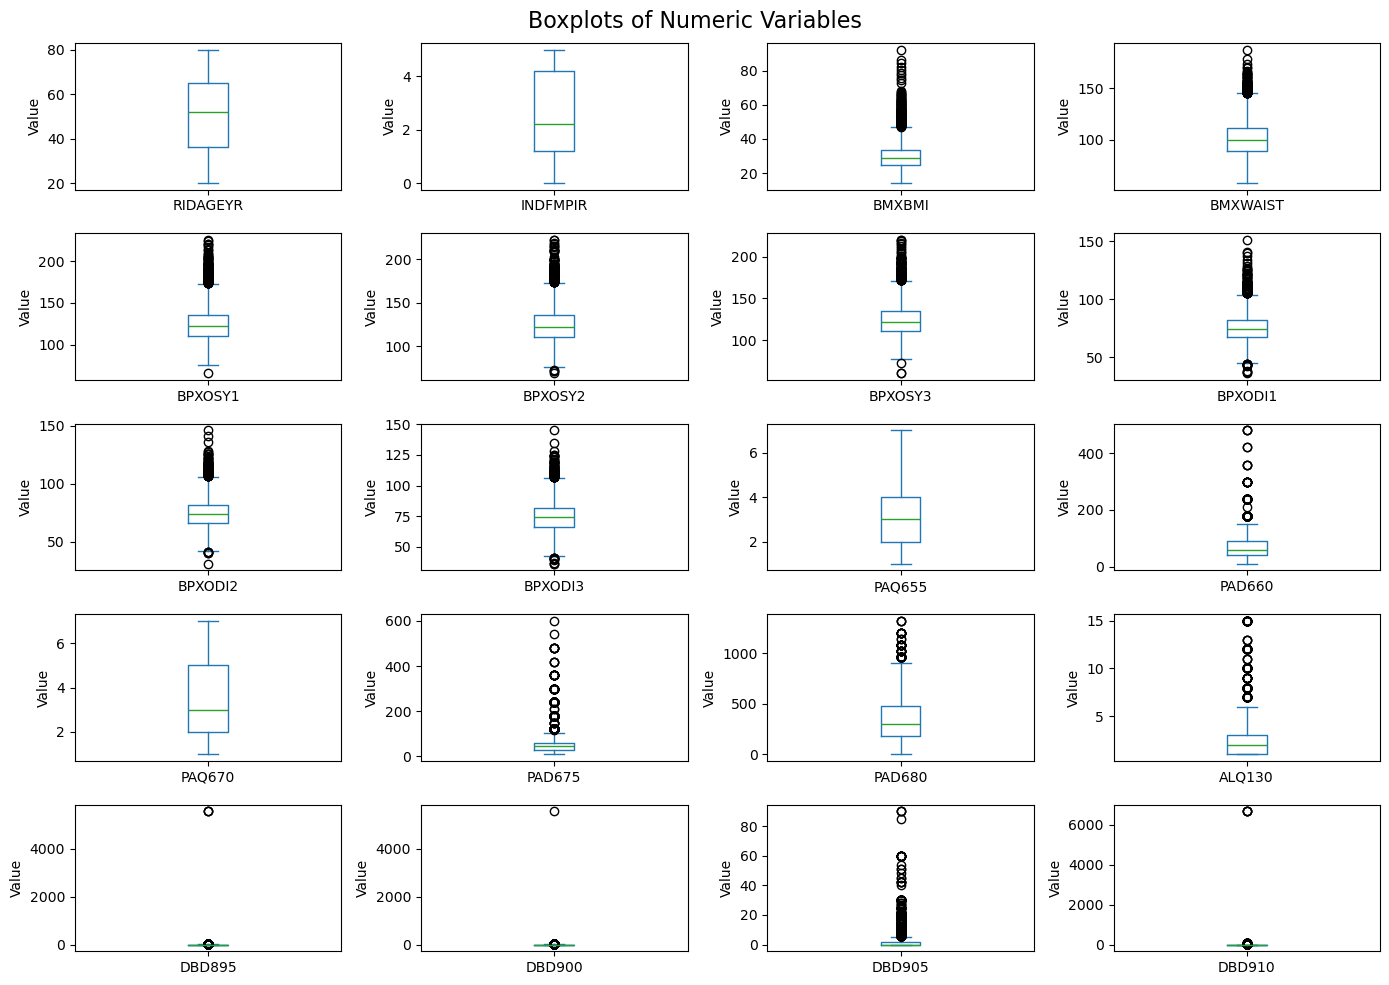

In [12]:
# Boxplots for numeric variables
axes = df_clean[numeric_cols].plot(
    kind="box",
    subplots=True,
    layout=(5, 4),
    figsize=(14, 10),
    sharex=False,
    sharey=False
)
plt.suptitle("Boxplots of Numeric Variables", fontsize=16)
axes_flat = np.array(axes).ravel()

for ax in axes_flat:
    ax.set_xlabel("")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.savefig(eda_dir / "Boxplots_numeric_variables.png", dpi=300, bbox_inches="tight")
plt.show()

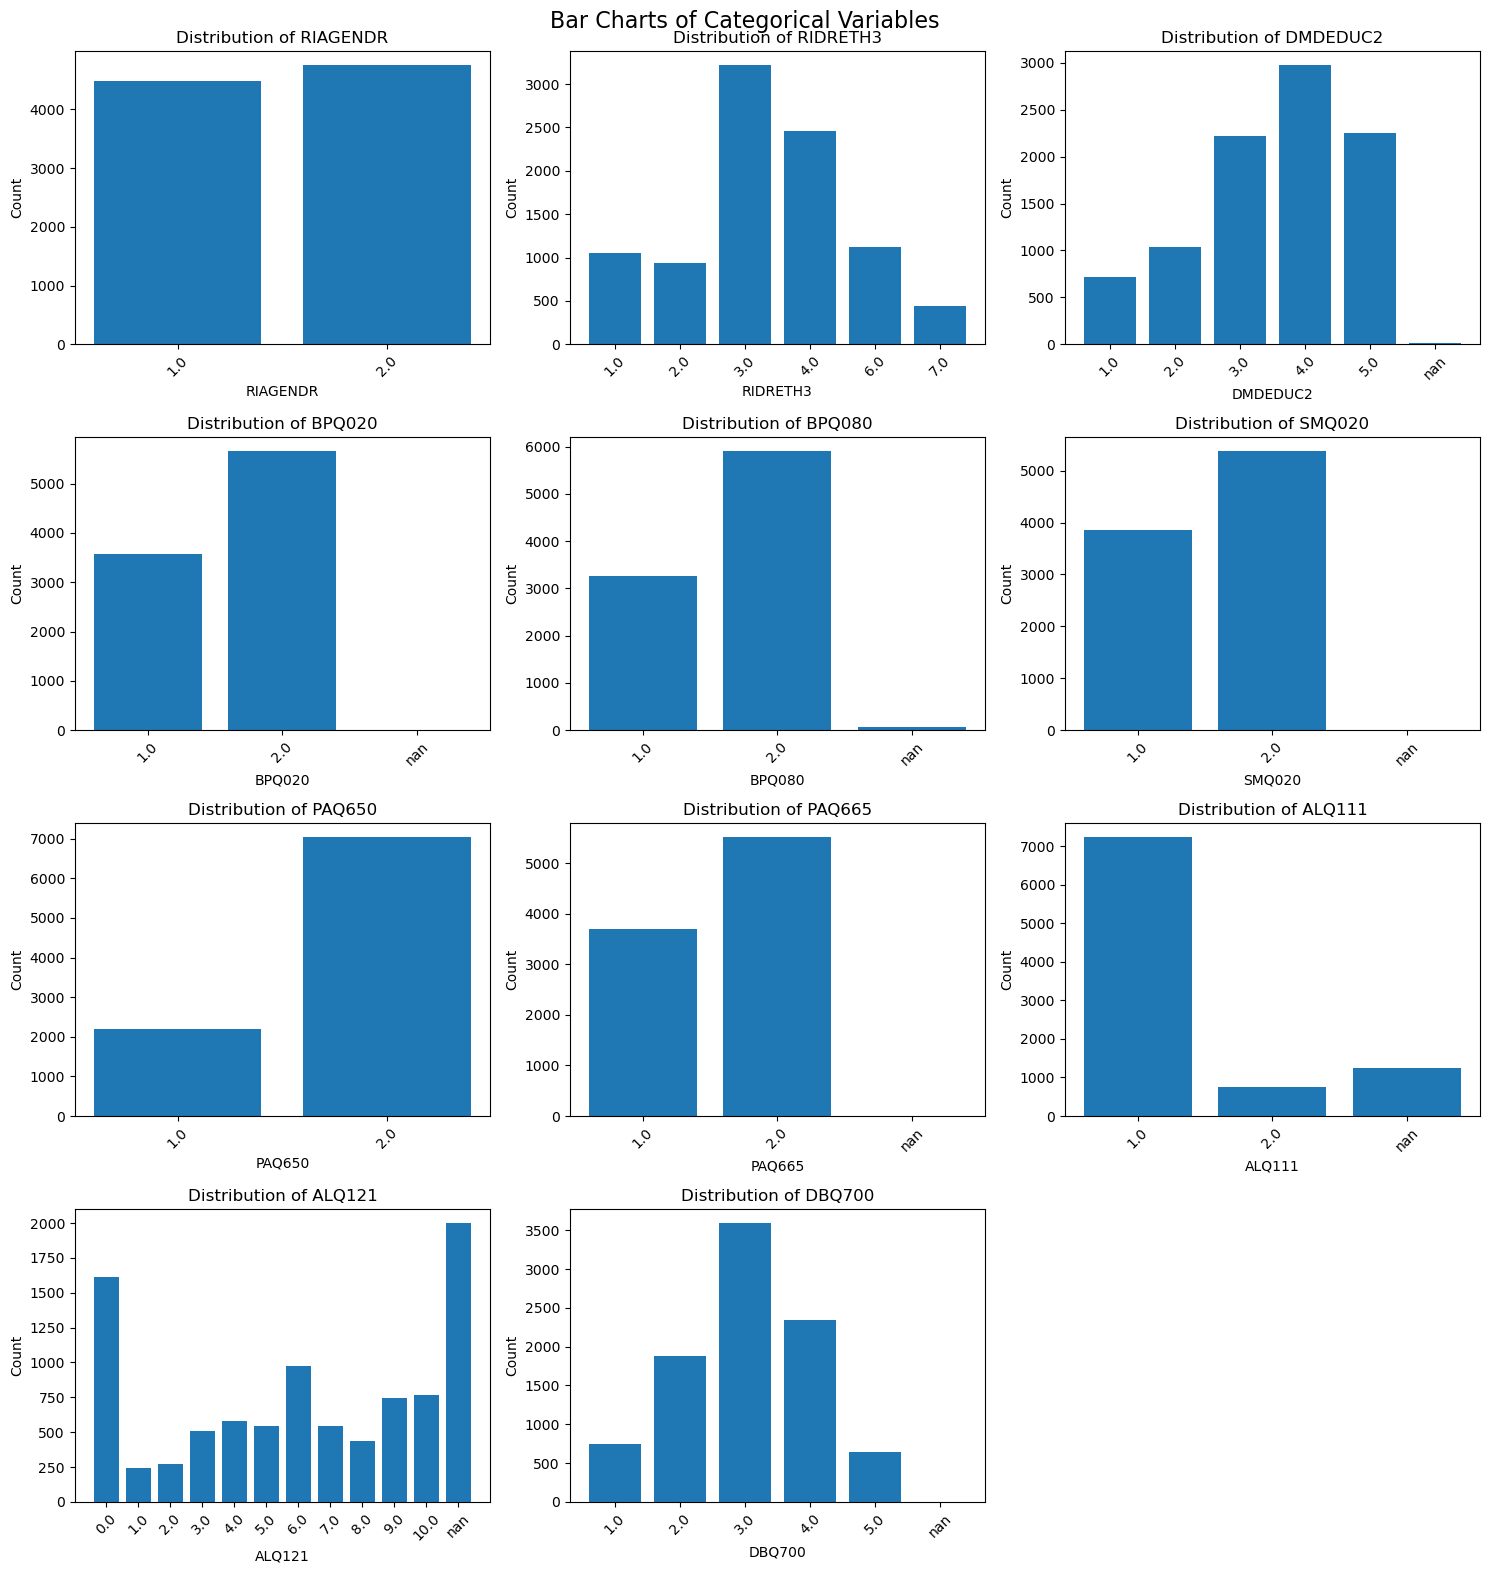

In [13]:
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df_clean[col].value_counts(dropna=False).sort_index()
    
    axes[i].bar(counts.index.astype(str), counts.values)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

# Hide empty plots if there are extra axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Bar Charts of Categorical Variables", fontsize=16)
plt.tight_layout()
plt.savefig(eda_dir / "distribution_categorical_variables.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Missing value summary
missing_table = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_percent": df_clean.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_table

,missing_count,missing_percent
PAD660,7047,76.332322
PAQ655,7041,76.267331
PAD675,5535,59.954506
PAQ670,5526,59.857019
LBXGLU,5228,56.629116
ALQ130,3619,39.200607
DBD900,2031,21.999567
ALQ121,2001,21.674610
BPXODI3,1613,17.471837
BPXOSY3,1613,17.471837


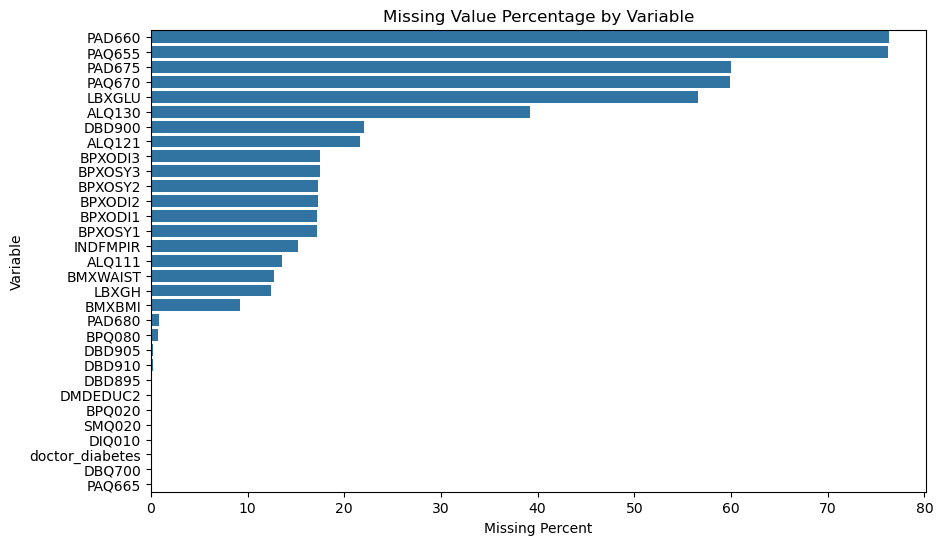

In [15]:
# Missingness bar plot 
missing_nonzero = missing_table[missing_table["missing_count"] > 0]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=missing_nonzero.reset_index(),
    x="missing_percent",
    y="index"
)
plt.title("Missing Value Percentage by Variable")
plt.xlabel("Missing Percent")
plt.ylabel("Variable")
plt.savefig(eda_dir / "missing_data_features_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

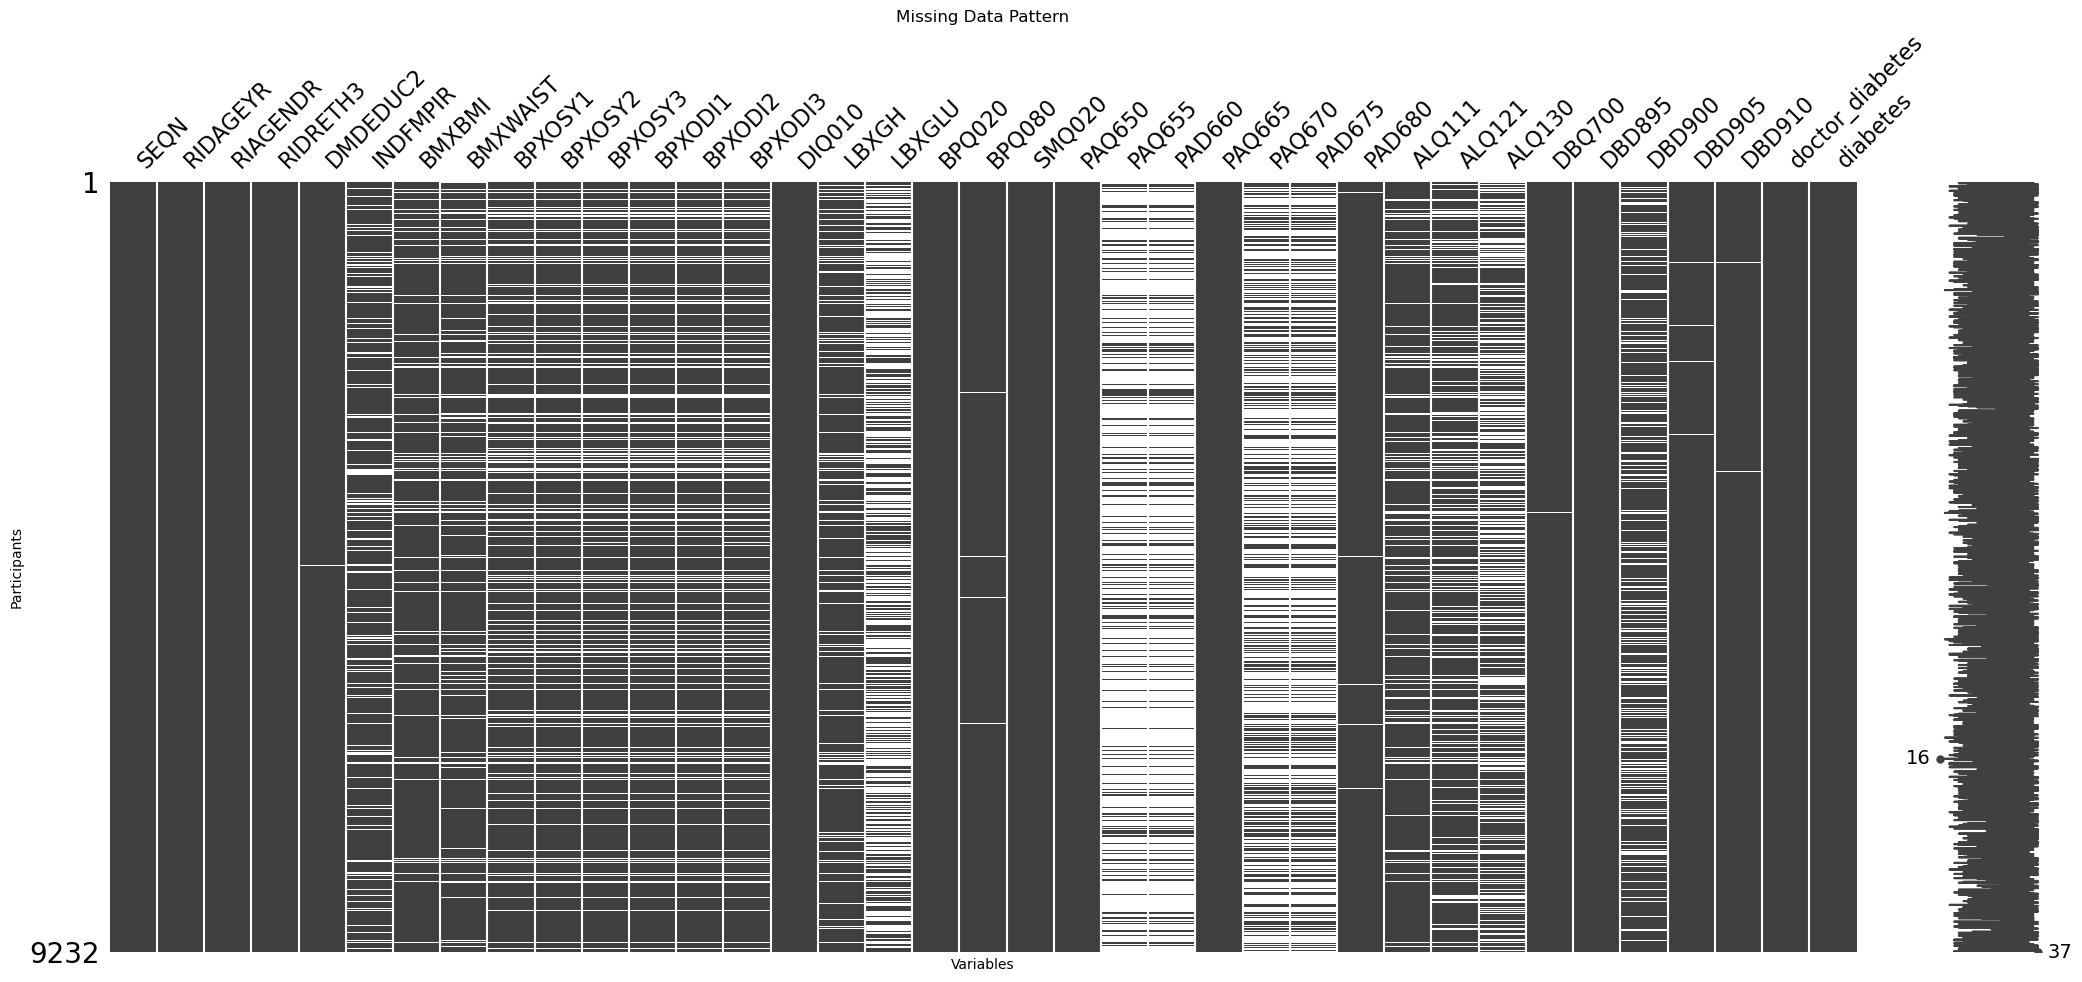

In [16]:
# Missingness matrix 
msno.matrix(df_clean)
plt.title("Missing Data Pattern")
plt.xlabel("Variables") 
plt.ylabel("Participants")
plt.savefig(eda_dir / "missing_data_pattern_hitmap.png", dpi=300, bbox_inches="tight")
plt.show()

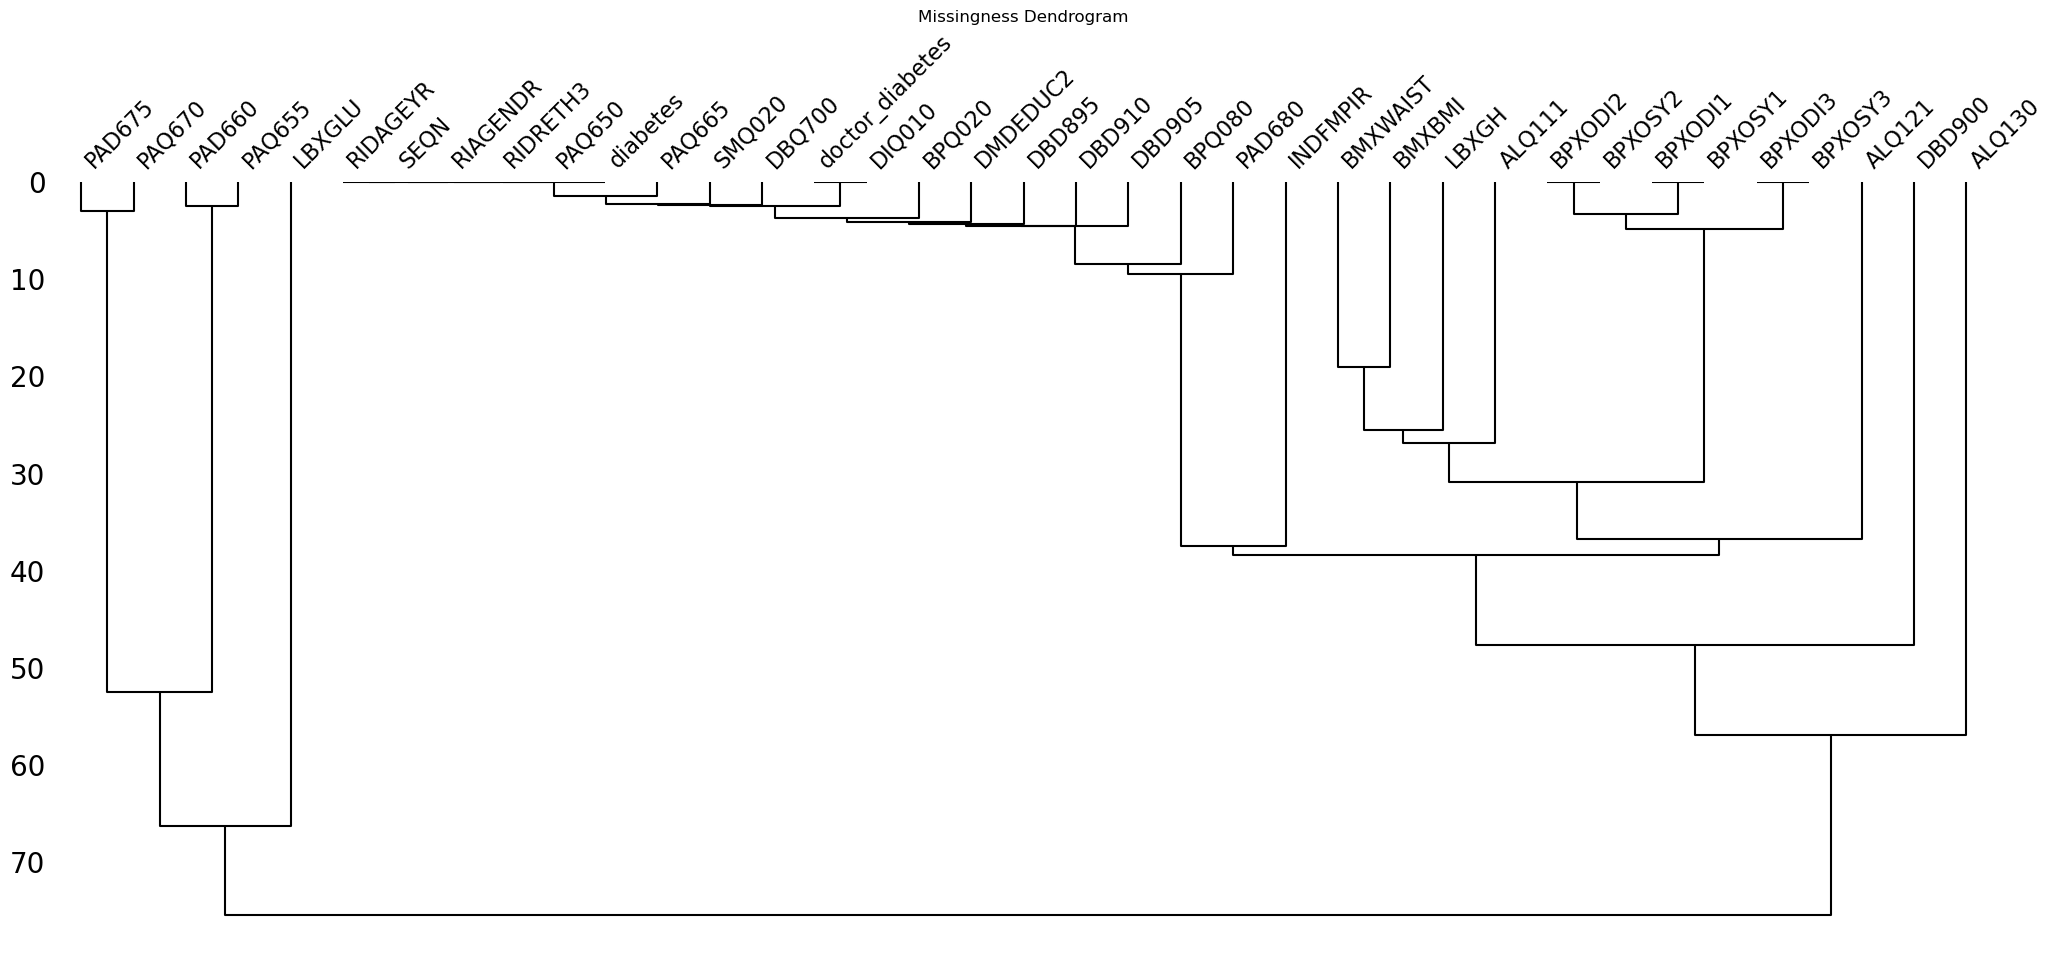

In [17]:
msno.dendrogram(df_clean)
plt.title("Missingness Dendrogram")
plt.savefig(eda_dir / "missingness_dendrogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
# Create age group for EDA
df_clean["age_group"] = pd.cut(
    df_clean["RIDAGEYR"],
    bins=[20, 30, 40, 50, 60, 70, 80],
    labels=["20-29", "30-39", "40-49", "50-59", "60-69", "70-80"],
    include_lowest=True
)

age_diabetes_table = pd.crosstab(
    df_clean["age_group"],
    df_clean["diabetes"],
    margins=True
)

age_diabetes_table

diabetes,0,1,All
age_group,,,
20-29,1483,32,1515
30-39,1334,89,1423
40-49,1214,239,1453
50-59,1252,399,1651
60-69,1119,543,1662
70-80,1010,518,1528
All,7412,1820,9232


In [20]:
#diabetes rate by age group
age_diabetes_rate = pd.crosstab(
    df_clean["age_group"],
    df_clean["diabetes"],
    normalize="index"
) * 100

age_diabetes_rate

diabetes,0,1
age_group,,
20-29,97.887789,2.112211
30-39,93.745608,6.254392
40-49,83.551273,16.448727
50-59,75.832829,24.167171
60-69,67.328520,32.671480
70-80,66.099476,33.900524


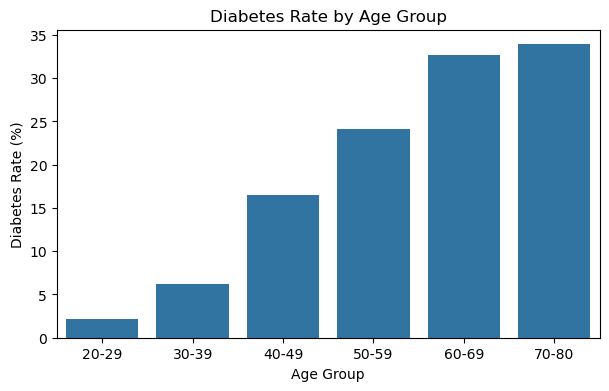

In [21]:
# Plot diabetes rate by age group
age_rate_plot = age_diabetes_rate[1].reset_index()
age_rate_plot.columns = ["age_group", "diabetes_rate"]

plt.figure(figsize=(7, 4))
sns.barplot(data=age_rate_plot, x="age_group", y="diabetes_rate")
plt.title("Diabetes Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Diabetes Rate (%)")
plt.savefig(eda_dir / "diabetes_rate_age_group.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
gender_table = pd.crosstab(
    df_clean["RIAGENDR"],
    df_clean["diabetes"],
    margins=True
)

gender_table

diabetes,0,1,All
RIAGENDR,,,
1.0,3523,956,4479
2.0,3889,864,4753
All,7412,1820,9232


In [23]:
gender_rate = pd.crosstab(
    df_clean["RIAGENDR"],
    df_clean["diabetes"],
    normalize="index"
) * 100

gender_rate

diabetes,0,1
RIAGENDR,,
1.0,78.655950,21.344050
2.0,81.822007,18.177993


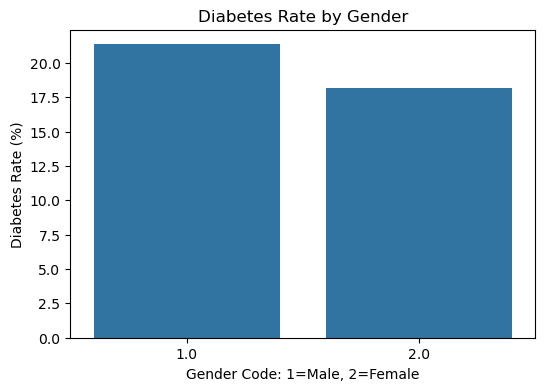

In [24]:
gender_rate_plot = gender_rate[1].reset_index()
gender_rate_plot.columns = ["RIAGENDR", "diabetes_rate"]

plt.figure(figsize=(6, 4))
sns.barplot(data=gender_rate_plot, x="RIAGENDR", y="diabetes_rate")
plt.title("Diabetes Rate by Gender")
plt.xlabel("Gender Code: 1=Male, 2=Female")
plt.ylabel("Diabetes Rate (%)")
plt.savefig(eda_dir / "diabetes_rate_gender.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
race_table = pd.crosstab(
    df_clean["RIDRETH3"],
    df_clean["diabetes"],
    margins=True
)

race_table

diabetes,0,1,All
RIDRETH3,,,
1.0,818,239,1057
2.0,740,200,940
3.0,2658,559,3217
4.0,1934,525,2459
6.0,911,209,1120
7.0,351,88,439
All,7412,1820,9232


In [26]:
race_rate = pd.crosstab(
    df_clean["RIDRETH3"],
    df_clean["diabetes"],
    normalize="index"
) * 100

race_rate

diabetes,0,1
RIDRETH3,,
1.0,77.388836,22.611164
2.0,78.723404,21.276596
3.0,82.623562,17.376438
4.0,78.649858,21.350142
6.0,81.339286,18.660714
7.0,79.954442,20.045558


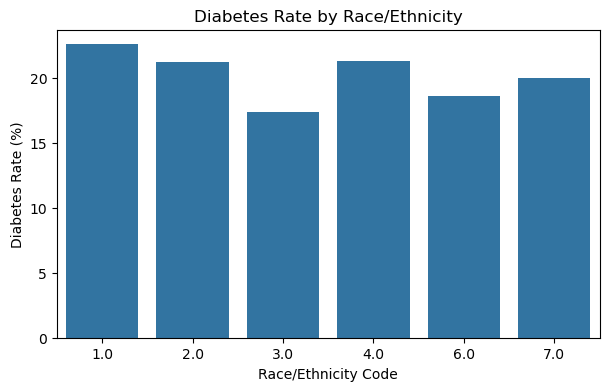

In [27]:
race_rate_plot = race_rate[1].reset_index()
race_rate_plot.columns = ["RIDRETH3", "diabetes_rate"]

plt.figure(figsize=(7, 4))
sns.barplot(data=race_rate_plot, x="RIDRETH3", y="diabetes_rate")
plt.title("Diabetes Rate by Race/Ethnicity")
plt.xlabel("Race/Ethnicity Code")
plt.ylabel("Diabetes Rate (%)")
plt.savefig(eda_dir / "diabetes_rate_race_ethnecity.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
education_rate = pd.crosstab(
    df_clean["DMDEDUC2"],
    df_clean["diabetes"],
    normalize="index"
) * 100

education_rate

diabetes,0,1
DMDEDUC2,,
1.0,67.037552,32.962448
2.0,76.176753,23.823247
3.0,79.730337,20.269663
4.0,81.714286,18.285714
5.0,85.068675,14.931325


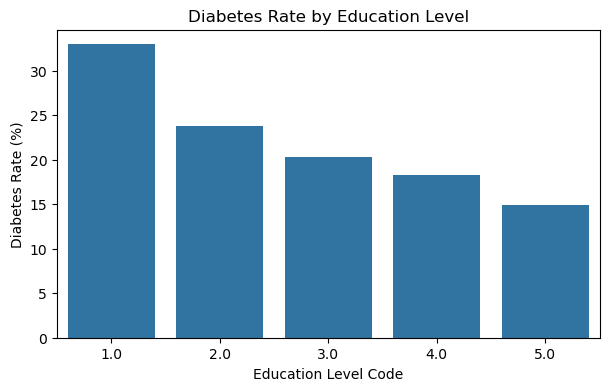

In [29]:
education_rate_plot = education_rate[1].reset_index()
education_rate_plot.columns = ["DMDEDUC2", "diabetes_rate"]

plt.figure(figsize=(7, 4))
sns.barplot(data=education_rate_plot, x="DMDEDUC2", y="diabetes_rate")
plt.title("Diabetes Rate by Education Level")
plt.xlabel("Education Level Code")
plt.ylabel("Diabetes Rate (%)")
plt.savefig(eda_dir / "diabetes_rate_education.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
#Compare numeric variables by diabetes status
# Mean numeric values by diabetes status
df_clean.groupby("diabetes")[numeric_cols].mean().T

diabetes,0,1
RIDAGEYR,48.522531,61.824725
INDFMPIR,2.643499,2.412932
BMXBMI,29.341786,32.834608
BMXWAIST,98.796754,109.920807
BPXOSY1,123.458845,131.500976
BPXOSY2,123.239882,130.965450
BPXOSY3,123.251641,130.437459
BPXODI1,75.143839,75.452830
BPXODI2,74.668688,74.516949
BPXODI3,74.391661,74.061559


In [31]:
# Median numeric values by diabetes status
df_clean.groupby("diabetes")[numeric_cols].median().T

diabetes,0,1
RIDAGEYR,48.00,63.000
INDFMPIR,2.32,1.925
BMXBMI,28.10,31.500
BMXWAIST,97.40,108.600
BPXOSY1,120.00,129.000
BPXOSY2,120.00,129.000
BPXOSY3,120.50,128.000
BPXODI1,74.00,75.000
BPXODI2,74.00,74.000
BPXODI3,74.00,74.000


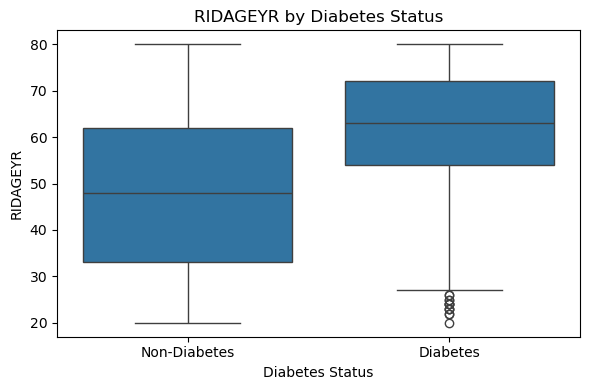

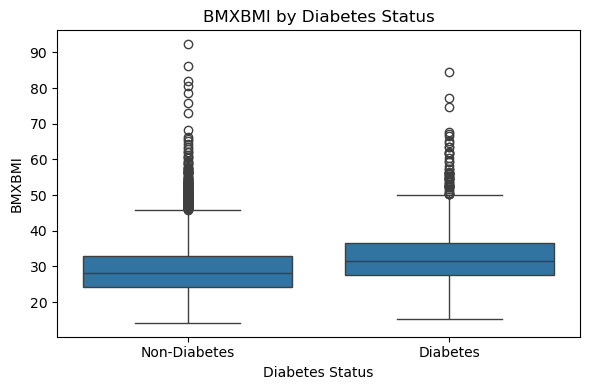

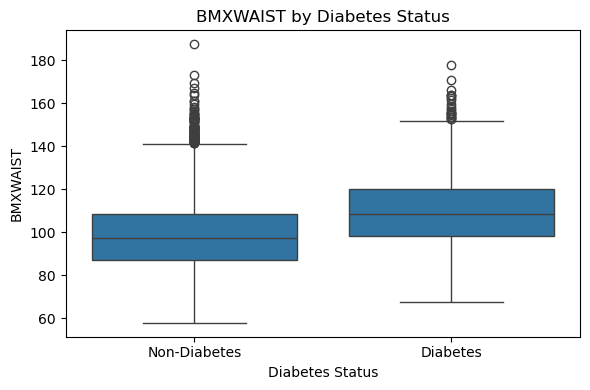

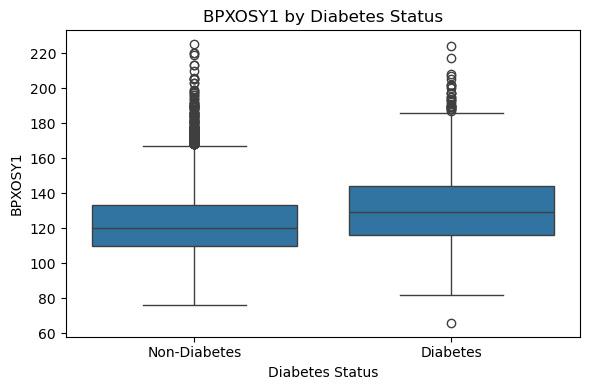

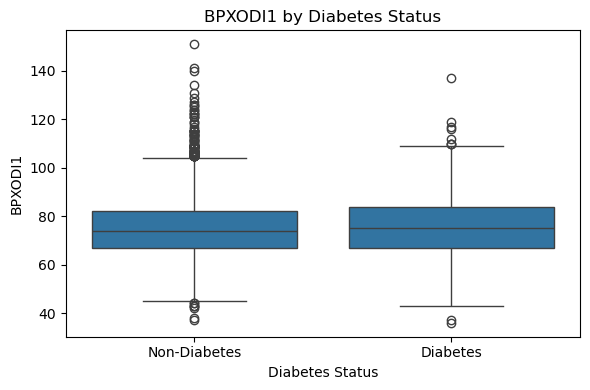

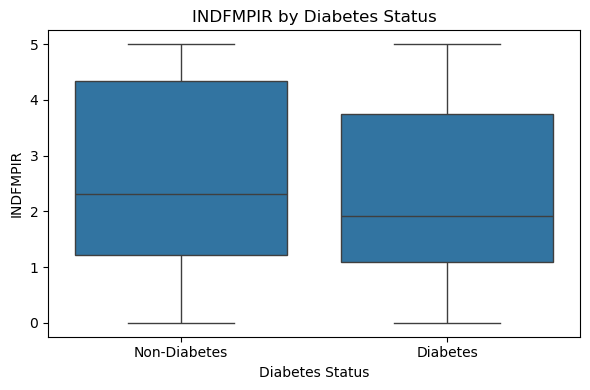

In [32]:
important_numeric = [
    "RIDAGEYR",
    "BMXBMI",
    "BMXWAIST",
    "BPXOSY1",
    "BPXODI1",
    "INDFMPIR"
]

important_numeric = [col for col in important_numeric if col in df_clean.columns]

for col in important_numeric:
    plt.figure(figsize=(6, 4))
    
    sns.boxplot(data=df_clean, x="diabetes", y=col)
    
    plt.title(f"{col} by Diabetes Status")
    plt.xlabel("Diabetes Status")
    plt.ylabel(col)
    plt.xticks([0, 1], ["Non-Diabetes", "Diabetes"])
    
    plt.tight_layout()
    
    # Different file name for each plot
    plt.savefig(
        eda_dir / f"{col}_by_diabetes_status.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

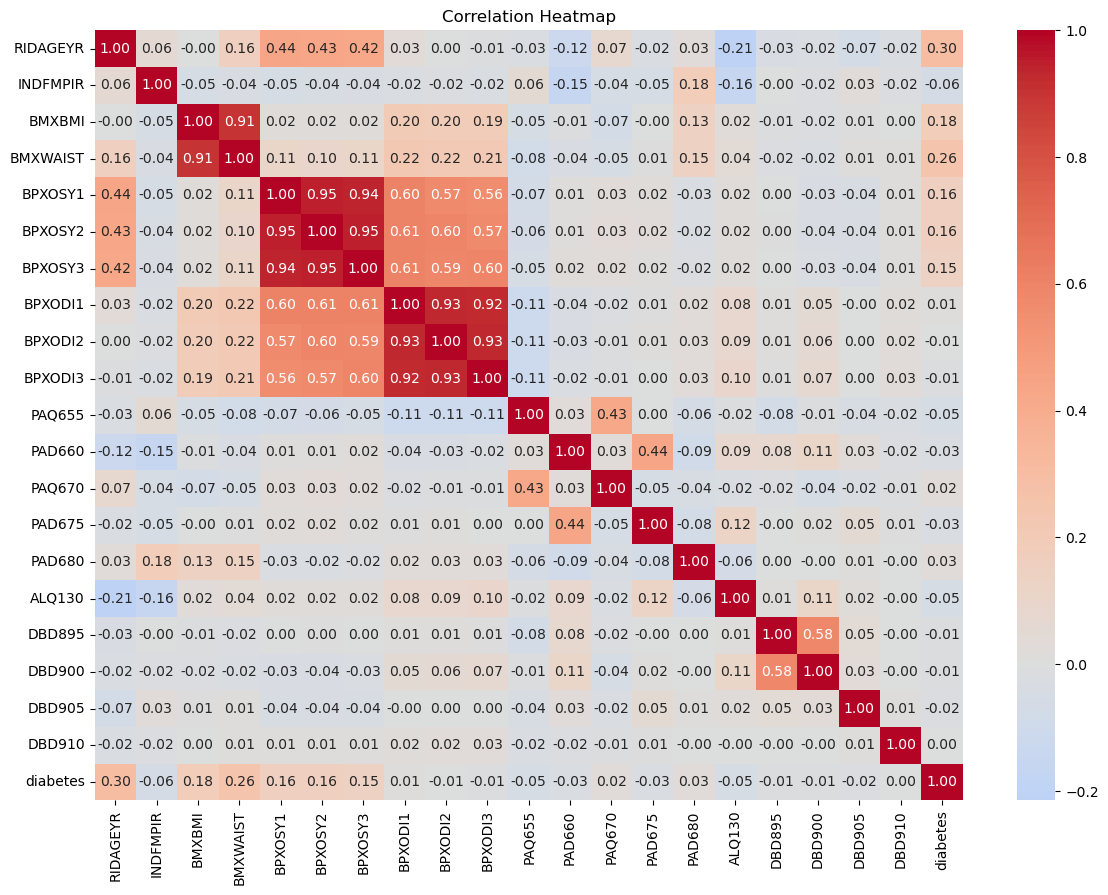

In [42]:
# Correlation among numeric variables and diabetes target
corr_cols = numeric_cols + ["diabetes"]
corr_cols = [col for col in corr_cols if col in df_clean.columns]

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot = True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig(eda_dir / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

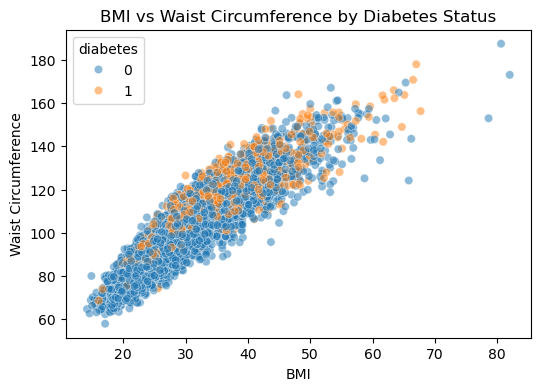

In [43]:
# Scatterplot relationship - BMI vs waist circumference
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_clean, x="BMXBMI", y="BMXWAIST", hue="diabetes", alpha=0.5)
plt.title("BMI vs Waist Circumference by Diabetes Status")
plt.xlabel("BMI")
plt.ylabel("Waist Circumference")
plt.savefig(eda_dir / "BMI_waist_circumference_diabetes_status.png", dpi=300, bbox_inches="tight")
plt.show()

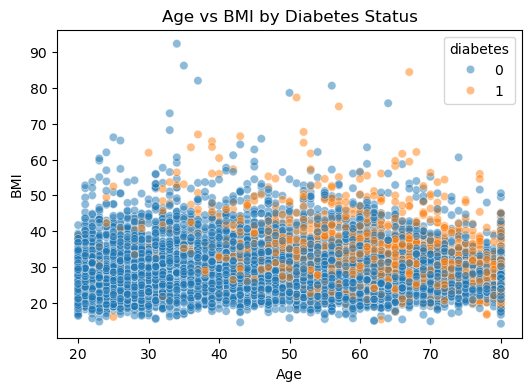

In [44]:
# Age vs BMI
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_clean, x="RIDAGEYR", y="BMXBMI", hue="diabetes", alpha=0.5)
plt.title("Age vs BMI by Diabetes Status")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.savefig(eda_dir / "age_vs_BMI_diabetes_status.png", dpi=300, bbox_inches="tight")
plt.show()

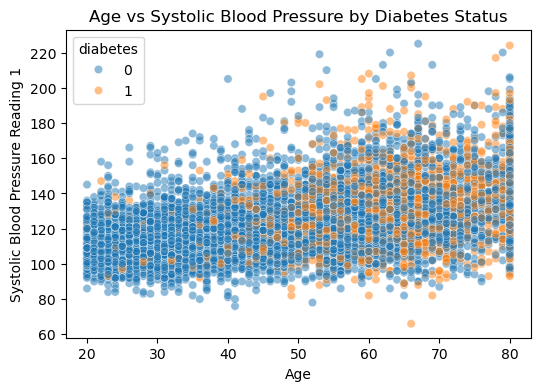

In [40]:
# Age vs Systolic blood pressure 
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_clean, x="RIDAGEYR", y="BPXOSY1", hue="diabetes", alpha=0.5)
plt.title("Age vs Systolic Blood Pressure by Diabetes Status")
plt.xlabel("Age")
plt.ylabel("Systolic Blood Pressure Reading 1")
plt.show()

In [41]:
def iqr_outlier_summary(data, columns):
    results = []

    for col in columns:
        series = data[col].dropna()
        
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        
        results.append({
            "variable": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": len(outliers),
            "outlier_percent": len(outliers) / len(data) * 100
        })

    return pd.DataFrame(results).sort_values("outlier_percent", ascending=False)

outlier_summary = iqr_outlier_summary(df_clean, numeric_cols)

outlier_summary

,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
19,DBD910,0.00,2.0000,2.0000,-3.00000,5.00000,953,10.322790
18,DBD905,0.00,2.0000,2.0000,-3.00000,5.00000,882,9.553726
16,DBD895,1.00,4.0000,3.0000,-3.50000,8.50000,738,7.993934
13,PAD675,30.00,60.0000,30.0000,-15.00000,105.00000,655,7.094887
17,DBD900,0.00,3.0000,3.0000,-4.50000,7.50000,279,3.022097
2,BMXBMI,24.90,33.8000,8.9000,11.55000,47.15000,259,2.805459
15,ALQ130,1.00,3.0000,2.0000,-2.00000,6.00000,242,2.621317
6,BPXOSY3,111.00,135.0000,24.0000,75.00000,171.00000,191,2.068891
4,BPXOSY1,111.00,136.0000,25.0000,73.50000,173.50000,182,1.971404
11,PAD660,40.00,90.0000,50.0000,-35.00000,165.00000,176,1.906412


In [42]:
range_summary = pd.DataFrame({
    "min": df_clean[numeric_cols].min(),
    "max": df_clean[numeric_cols].max(),
    "mean": df_clean[numeric_cols].mean(),
    "median": df_clean[numeric_cols].median()
})

range_summary

,min,max,mean,median
RIDAGEYR,2.000000e+01,80.0,51.144931,52.00
INDFMPIR,5.397605e-79,5.0,2.597786,2.21
BMXBMI,1.420000e+01,92.3,30.039017,28.80
BMXWAIST,5.790000e+01,187.5,100.987039,99.50
BPXOSY1,6.600000e+01,225.0,125.075052,122.00
BPXOSY2,6.900000e+01,222.0,124.791672,122.00
BPXOSY3,6.000000e+01,220.0,124.691823,122.00
BPXODI1,3.600000e+01,151.0,75.205936,74.00
BPXODI2,3.100000e+01,146.0,74.638209,74.00
BPXODI3,3.600000e+01,145.0,74.325502,74.00


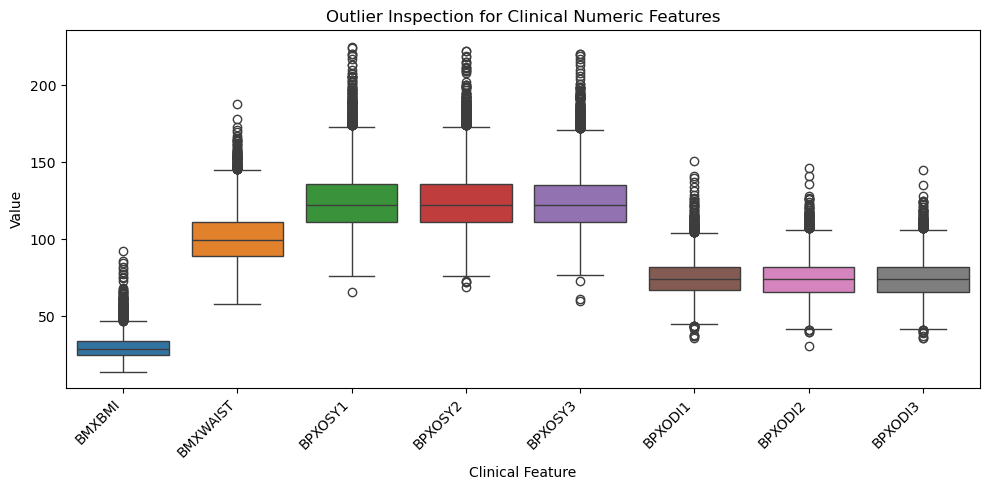

In [46]:
clinical_cols = [
    "BMXBMI",
    "BMXWAIST",
    "BPXOSY1",
    "BPXOSY2",
    "BPXOSY3",
    "BPXODI1",
    "BPXODI2",
    "BPXODI3"
]

clinical_cols = [col for col in clinical_cols if col in df_clean.columns]

plt.figure(figsize=(10, 5))

sns.boxplot(data=df_clean[clinical_cols])

plt.title("Outlier Inspection for Clinical Numeric Features")
plt.xlabel("Clinical Feature")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(eda_dir / "outlier_inspection_clinical_features.png", dpi=300, bbox_inches="tight")
plt.show()